# Atividade — Desocupação por sexo (2012 x 2026) e horas de afazeres domésticos (2022)

**Aluno:** Migss — COTEMIG

**O que vamos fazer:**
1. Abrir as duas **Tabelas 5** (composição da desocupação por sexo em 2012 T1 e 2026 T1);
2. **Juntar** as duas tabelas com `merge`;
3. **Comparar ano a ano** (variação em pontos percentuais);
4. **Cruzar** com a **Tabela 1.1.1** do IBGE (horas semanais de cuidados e afazeres domésticos, 2022 — Aula 2);
5. Gerar gráficos e escrever as conclusões.

**Fontes:** IBGE — PNAD Contínua (desocupação por sexo) e PNAD Contínua 2022, Tabela 1.1.1 (afazeres domésticos).

## 1. Importando as bibliotecas

In [1]:
# pandas: trabalhar com tabelas (DataFrames)
# matplotlib: fazer os gráficos
import pandas as pd
import matplotlib.pyplot as plt

# Mostra os números com no máximo 2 casas decimais (fica mais legível)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Bibliotecas importadas com sucesso!")
print("Versão do pandas:", pd.__version__)

Bibliotecas importadas com sucesso!
Versão do pandas: 3.0.2


## 2. Abrindo as duas Tabelas 5

Os dois arquivos são CSV do IBGE, então precisamos avisar ao pandas que:
- o separador de colunas é `;` (ponto e vírgula);
- o separador decimal é `,` (vírgula), como no padrão brasileiro;
- a codificação é `utf-8-sig` (assim os acentos aparecem certinho).

In [2]:
# Caminho dos arquivos (se rodar no seu PC, troque pelo caminho da sua pasta)
caminho_2012 = "Tabela5-sem_emprego_2012.csv"
caminho_2026 = "Tabela5-sem_emprego_2026.csv"
caminho_xls  = "Tabela_1_1_1.xls"

# Lendo a Tabela 5 de 2012
t2012 = pd.read_csv(caminho_2012, sep=";", decimal=",", encoding="utf-8-sig")

# Lendo a Tabela 5 de 2026
t2026 = pd.read_csv(caminho_2026, sep=";", decimal=",", encoding="utf-8-sig")

print("Tabela 2012 -> linhas e colunas:", t2012.shape)
print("Tabela 2026 -> linhas e colunas:", t2026.shape)

t2012.head()

Tabela 2012 -> linhas e colunas: (27, 5)
Tabela 2026 -> linhas e colunas: (27, 5)


,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.30,54.70
1,AL,27,Alagoas,44.70,55.30
2,AM,13,Amazonas,47.50,52.50
3,AP,16,Amapá,48.10,51.90
4,BA,29,Bahia,43.80,56.20


In [3]:
# Espiando a tabela de 2026
t2026.head()

,Sigla,Código,Estado,Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,53.20,46.80
1,AL,27,Alagoas,50.70,49.30
2,AM,13,Amazonas,46.80,53.20
3,AP,16,Amapá,51.10,48.90
4,BA,29,Bahia,44.70,55.30


In [4]:
# Conferindo os tipos de cada coluna (os percentuais precisam ser float)
print("=== Tipos da tabela 2012 ===")
print(t2012.dtypes)
print()
print("=== Tipos da tabela 2026 ===")
print(t2026.dtypes)

=== Tipos da tabela 2012 ===
Sigla                                   str
Código                                int64
Estado                                  str
Desocupados - homens (2012 T1)      float64
Desocupados - mulheres (2012 T1)    float64
dtype: object

=== Tipos da tabela 2026 ===
Sigla                                   str
Código                                int64
Estado                                  str
Desocupados - homens (2026 T1)      float64
Desocupados - mulheres (2026 T1)    float64
dtype: object


## 3. Juntando as duas Tabelas 5

Usamos `merge` com as três colunas que existem nas duas tabelas: `Sigla`, `Código` e `Estado`.
O `how="inner"` mantém apenas os estados que aparecem nas **duas** tabelas.

In [5]:
# Juntando (merge) as duas Tabelas 5
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

print("Tabela juntada:", comp.shape[0], "linhas e", comp.shape[1], "colunas")
print("Colunas:", list(comp.columns))

comp.head(10)

Tabela juntada: 27 linhas e 7 colunas
Colunas: ['Sigla', 'Código', 'Estado', 'Desocupados - homens (2012 T1)', 'Desocupados - mulheres (2012 T1)', 'Desocupados - homens (2026 T1)', 'Desocupados - mulheres (2026 T1)']


,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1),Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,45.30,54.70,53.20,46.80
1,AL,27,Alagoas,44.70,55.30,50.70,49.30
2,AM,13,Amazonas,47.50,52.50,46.80,53.20
3,AP,16,Amapá,48.10,51.90,51.10,48.90
4,BA,29,Bahia,43.80,56.20,44.70,55.30
5,CE,23,Ceará,51.10,48.90,52.70,47.30
6,DF,53,Distrito Federal,41.00,59.00,47.90,52.10
7,ES,32,Espírito Santo,46.40,53.60,47.50,52.50
8,GO,52,Goiás,41.00,59.00,47.50,52.50
9,MA,21,Maranhão,47.20,52.80,49.10,50.90


In [6]:
# Conferência importante: o merge manteve os 27 estados?
print("Estados em 2012:", len(t2012))
print("Estados em 2026:", len(t2026))
print("Estados após o merge:", len(comp))

if len(comp) == len(t2012) == len(t2026):
    print("\nOK! Nenhum estado foi perdido no merge.")
else:
    print("\nATENÇÃO: algum estado ficou de fora.")

Estados em 2012: 27
Estados em 2026: 27
Estados após o merge: 27

OK! Nenhum estado foi perdido no merge.


## 4. Comparando ano a ano (2012 x 2026)

Como os valores são **percentuais** (participação de homens e mulheres no total de desocupados),
a comparação é feita em **pontos percentuais (p.p.)**:

`variação = valor de 2026 − valor de 2012`

In [7]:
# Deixando os nomes das colunas mais curtos para facilitar
comp = comp.rename(columns={
    "Desocupados - homens (2012 T1)":   "Homens_2012",
    "Desocupados - mulheres (2012 T1)": "Mulheres_2012",
    "Desocupados - homens (2026 T1)":   "Homens_2026",
    "Desocupados - mulheres (2026 T1)": "Mulheres_2026",
})

# Variação em pontos percentuais (2026 - 2012)
comp["Var_homens_pp"]   = comp["Homens_2026"]   - comp["Homens_2012"]
comp["Var_mulheres_pp"] = comp["Mulheres_2026"] - comp["Mulheres_2012"]

# Diferença entre mulheres e homens dentro de cada ano
comp["Dif_M_H_2012"] = comp["Mulheres_2012"] - comp["Homens_2012"]
comp["Dif_M_H_2026"] = comp["Mulheres_2026"] - comp["Homens_2026"]

comp[["Sigla", "Estado", "Homens_2012", "Mulheres_2012",
      "Homens_2026", "Mulheres_2026", "Var_mulheres_pp"]].head(10)

,Sigla,Estado,Homens_2012,Mulheres_2012,Homens_2026,Mulheres_2026,Var_mulheres_pp
0,AC,Acre,45.30,54.70,53.20,46.80,-7.90
1,AL,Alagoas,44.70,55.30,50.70,49.30,-6.00
2,AM,Amazonas,47.50,52.50,46.80,53.20,0.70
3,AP,Amapá,48.10,51.90,51.10,48.90,-3.00
4,BA,Bahia,43.80,56.20,44.70,55.30,-0.90
5,CE,Ceará,51.10,48.90,52.70,47.30,-1.60
6,DF,Distrito Federal,41.00,59.00,47.90,52.10,-6.90
7,ES,Espírito Santo,46.40,53.60,47.50,52.50,-1.10
8,GO,Goiás,41.00,59.00,47.50,52.50,-6.50
9,MA,Maranhão,47.20,52.80,49.10,50.90,-1.90


In [8]:
# Resumo geral (média dos 27 estados)
print("=== MÉDIA DOS 27 ESTADOS ===")
print(f"Homens desocupados   2012: {comp['Homens_2012'].mean():.2f}%")
print(f"Mulheres desocupadas 2012: {comp['Mulheres_2012'].mean():.2f}%")
print(f"Homens desocupados   2026: {comp['Homens_2026'].mean():.2f}%")
print(f"Mulheres desocupadas 2026: {comp['Mulheres_2026'].mean():.2f}%")
print()
print(f"Variação média da participação das mulheres: {comp['Var_mulheres_pp'].mean():.2f} p.p.")
print()
print("Estados em que a participação das mulheres AUMENTOU:",
      (comp["Var_mulheres_pp"] > 0).sum())
print("Estados em que a participação das mulheres DIMINUIU:",
      (comp["Var_mulheres_pp"] < 0).sum())

=== MÉDIA DOS 27 ESTADOS ===
Homens desocupados   2012: 45.43%
Mulheres desocupadas 2012: 54.57%
Homens desocupados   2026: 47.03%
Mulheres desocupadas 2026: 52.97%

Variação média da participação das mulheres: -1.60 p.p.

Estados em que a participação das mulheres AUMENTOU: 7
Estados em que a participação das mulheres DIMINUIU: 20


In [9]:
# Os 5 estados em que a participação feminina mais CAIU
print("=== MAIORES QUEDAS na participação feminina (p.p.) ===")
print(comp.nsmallest(5, "Var_mulheres_pp")[["Sigla", "Estado", "Mulheres_2012", "Mulheres_2026", "Var_mulheres_pp"]]
      .to_string(index=False))

print()
print("=== MAIORES ALTAS na participação feminina (p.p.) ===")
print(comp.nlargest(5, "Var_mulheres_pp")[["Sigla", "Estado", "Mulheres_2012", "Mulheres_2026", "Var_mulheres_pp"]]
      .to_string(index=False))

=== MAIORES QUEDAS na participação feminina (p.p.) ===
Sigla           Estado  Mulheres_2012  Mulheres_2026  Var_mulheres_pp
   AC             Acre          54.70          46.80            -7.90
   DF Distrito Federal          59.00          52.10            -6.90
   GO            Goiás          59.00          52.50            -6.50
   AL          Alagoas          55.30          49.30            -6.00
   PR           Paraná          59.70          53.70            -6.00

=== MAIORES ALTAS na participação feminina (p.p.) ===
Sigla              Estado  Mulheres_2012  Mulheres_2026  Var_mulheres_pp
   RO            Rondônia          56.60          67.00            10.40
   TO           Tocantins          44.70          53.80             9.10
   SE             Sergipe          53.50          59.70             6.20
   RN Rio Grande do Norte          49.00          51.80             2.80
   MS  Mato Grosso do Sul          52.80          54.70             1.90


### 4.1 Gráfico: participação das mulheres na desocupação (2012 x 2026)

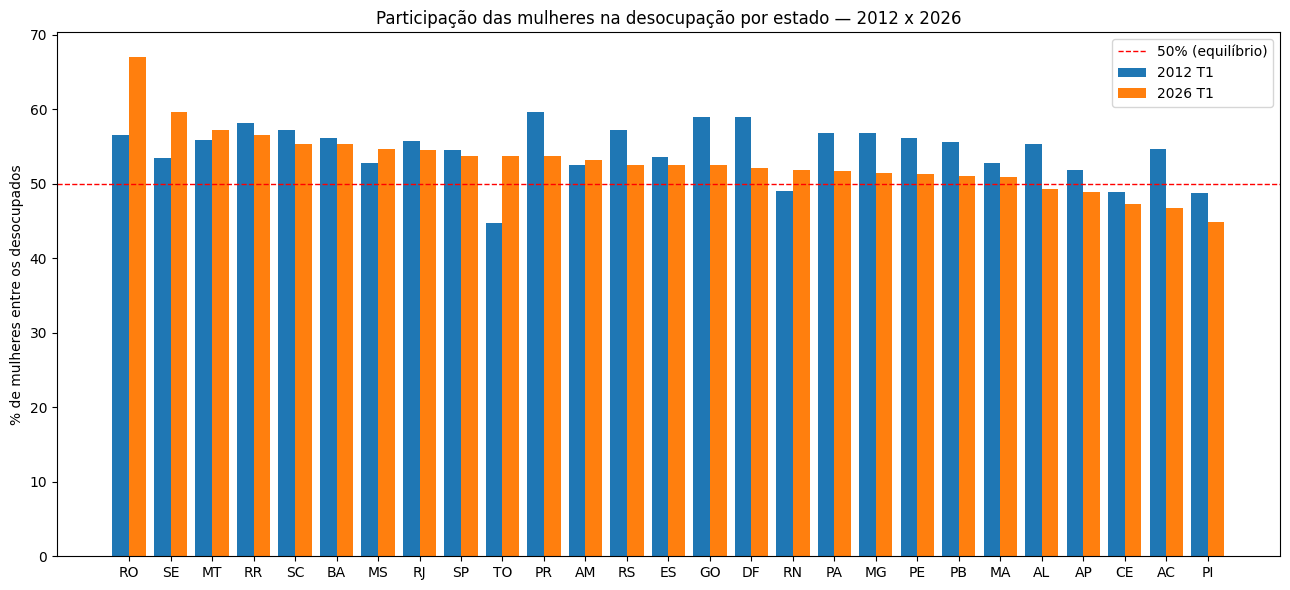

In [10]:
# Ordenando pelos estados com maior participação feminina em 2026
g = comp.sort_values("Mulheres_2026", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(g))
largura = 0.4

ax.bar([i - largura/2 for i in x], g["Mulheres_2012"], width=largura, label="2012 T1")
ax.bar([i + largura/2 for i in x], g["Mulheres_2026"], width=largura, label="2026 T1")

ax.axhline(50, color="red", linestyle="--", linewidth=1, label="50% (equilíbrio)")
ax.set_xticks(list(x))
ax.set_xticklabels(g["Sigla"])
ax.set_ylabel("% de mulheres entre os desocupados")
ax.set_title("Participação das mulheres na desocupação por estado — 2012 x 2026")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Gráfico: variação em pontos percentuais

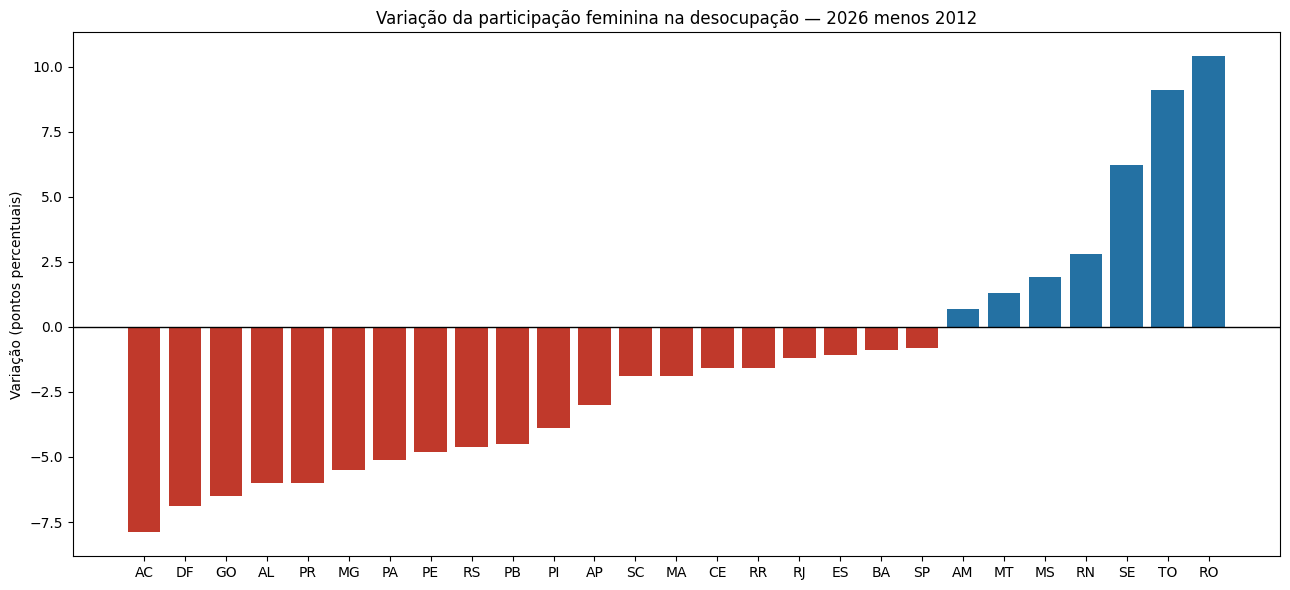

In [11]:
g2 = comp.sort_values("Var_mulheres_pp")

# Cor vermelha quando a participação feminina caiu e azul quando subiu
cores = ["#c0392b" if v < 0 else "#2471a3" for v in g2["Var_mulheres_pp"]]

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(g2["Sigla"], g2["Var_mulheres_pp"], color=cores)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Variação (pontos percentuais)")
ax.set_title("Variação da participação feminina na desocupação — 2026 menos 2012")
plt.tight_layout()
plt.show()

## 5. Abrindo a Tabela 1.1.1 do IBGE (Aula 2)

Essa planilha traz o **número médio de horas semanais** dedicadas a cuidados de pessoas
e/ou afazeres domésticos (pessoas de 14 anos ou mais), em **2022**, por sexo e cor ou raça.

O arquivo do IBGE vem "bagunçado": as 8 primeiras linhas são título e cabeçalhos em vários níveis,
e no fim tem a fonte e as notas. Por isso usamos `skiprows` e `nrows` e nomeamos as colunas na mão.

In [12]:
# Olhando primeiro como o arquivo é por dentro (sem cabeçalho nenhum)
espiada = pd.read_excel(caminho_xls, sheet_name="2022", header=None)
espiada.head(12)

,0,1,2,3,4,5,6,7
0,Tabela 1.1.1 - Número médio de horas semanais ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Grandes Regiões e Unidades da Federação,Número médio de horas semanais dedicadas aos c...,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Total,Por sexo e cor ou raça,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,Total,NaN,Homem,NaN,Mulher,NaN
7,NaN,NaN,Branca,Preta ou parda,Branca,Preta ou parda,Branca,Preta ou parda
8,Brasil,16.99,16.55,17.33,11.71,11.75,20.40,22.04
9,Norte,16.19,15.93,16.26,11.59,11.51,19.30,20.53


In [13]:
# Lendo só o miolo da planilha:
# skiprows=8 -> pula título e cabeçalhos
# nrows=33   -> Brasil + 5 grandes regiões + 27 unidades da federação
horas_bruto = pd.read_excel(caminho_xls, sheet_name="2022", header=None,
                            skiprows=8, nrows=33)

# Nomeando as colunas na mão, seguindo o cabeçalho original da planilha
horas_bruto.columns = [
    "Local",
    "Total",
    "Total_Branca", "Total_PretaParda",
    "Homem_Branca", "Homem_PretaParda",
    "Mulher_Branca", "Mulher_PretaParda",
]

horas_bruto.head(10)

,Local,Total,Total_Branca,Total_PretaParda,Homem_Branca,Homem_PretaParda,Mulher_Branca,Mulher_PretaParda
0,Brasil,16.99,16.55,17.33,11.71,11.75,20.40,22.04
1,Norte,16.19,15.93,16.26,11.59,11.51,19.30,20.53
2,Rondônia,17.01,16.73,17.10,12.11,12.54,20.41,21.06
3,Acre,13.61,13.81,13.54,10.80,9.69,16.13,16.71
4,Amazonas,16.81,15.99,17.00,12.23,12.82,18.76,20.72
5,Roraima,13.64,13.65,13.63,10.81,10.48,16.14,16.56
6,Pará,16.47,16.18,16.56,11.52,11.03,19.84,21.59
7,Amapá,13.59,14.39,13.42,11.12,10.75,16.65,15.91
8,Tocantins,15.82,15.70,15.77,10.73,11.68,19.66,19.63
9,Nordeste,18.50,18.15,18.61,11.72,11.85,22.74,23.72


In [14]:
# Tirando o Brasil e as grandes regiões: queremos só os 27 estados
regioes = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
horas = horas_bruto[~horas_bruto["Local"].isin(regioes)].copy()

# A planilha separa por cor/raça. Para comparar por SEXO, fazemos a média
# simples entre "Branca" e "Preta ou parda" (média não ponderada, é uma aproximação).
horas["Horas_homens"]   = horas[["Homem_Branca",  "Homem_PretaParda"]].mean(axis=1)
horas["Horas_mulheres"] = horas[["Mulher_Branca", "Mulher_PretaParda"]].mean(axis=1)

# Diferença de carga: quantas horas a mais as mulheres dedicam
horas["Dif_horas_M_H"] = horas["Horas_mulheres"] - horas["Horas_homens"]

# Renomeando a coluna do estado para bater com as Tabelas 5
horas = horas.rename(columns={"Local": "Estado", "Total": "Horas_total"})
horas = horas[["Estado", "Horas_total", "Horas_homens", "Horas_mulheres", "Dif_horas_M_H"]]

print("Estados na Tabela 1.1.1:", len(horas))
horas.head(10)

Estados na Tabela 1.1.1: 27


,Estado,Horas_total,Horas_homens,Horas_mulheres,Dif_horas_M_H
2,Rondônia,17.01,12.33,20.74,8.41
3,Acre,13.61,10.24,16.42,6.18
4,Amazonas,16.81,12.53,19.74,7.21
5,Roraima,13.64,10.65,16.35,5.70
6,Pará,16.47,11.28,20.71,9.44
7,Amapá,13.59,10.93,16.28,5.35
8,Tocantins,15.82,11.21,19.65,8.44
10,Maranhão,16.67,11.55,20.31,8.76
11,Piauí,17.96,11.73,22.09,10.36
12,Ceará,19.50,12.50,23.99,11.48


## 6. Cruzando as Tabelas 5 com a Tabela 1.1.1

Agora juntamos tudo pela coluna `Estado`. Antes, uma limpeza de segurança: tiramos espaços
extras dos nomes para o `merge` não deixar nenhum estado de fora.

In [15]:
# Limpeza: tirando espaços em branco antes e depois dos nomes
comp["Estado"]  = comp["Estado"].str.strip()
horas["Estado"] = horas["Estado"].str.strip()

# Conferindo se algum nome não bate entre as duas tabelas
sem_par = set(comp["Estado"]) - set(horas["Estado"])
print("Estados que não encontraram par:", sem_par if sem_par else "nenhum")

Estados que não encontraram par: nenhum


In [16]:
# Merge final: Tabelas 5 juntadas + Tabela 1.1.1
final = comp.merge(horas, on="Estado", how="inner")

print("Tabela final:", final.shape[0], "linhas e", final.shape[1], "colunas")
final.head(10)

Tabela final: 27 linhas e 15 colunas


,Sigla,Código,Estado,Homens_2012,Mulheres_2012,Homens_2026,Mulheres_2026,Var_homens_pp,Var_mulheres_pp,Dif_M_H_2012,Dif_M_H_2026,Horas_total,Horas_homens,Horas_mulheres,Dif_horas_M_H
0,AC,12,Acre,45.30,54.70,53.20,46.80,7.90,-7.90,9.40,-6.40,13.61,10.24,16.42,6.18
1,AL,27,Alagoas,44.70,55.30,50.70,49.30,6.00,-6.00,10.60,-1.40,20.22,12.74,24.98,12.24
2,AM,13,Amazonas,47.50,52.50,46.80,53.20,-0.70,0.70,5.00,6.40,16.81,12.53,19.74,7.21
3,AP,16,Amapá,48.10,51.90,51.10,48.90,3.00,-3.00,3.80,-2.20,13.59,10.93,16.28,5.35
4,BA,29,Bahia,43.80,56.20,44.70,55.30,0.90,-0.90,12.40,10.60,17.85,10.77,22.89,12.13
5,CE,23,Ceará,51.10,48.90,52.70,47.30,1.60,-1.60,-2.20,-5.40,19.50,12.50,23.99,11.48
6,DF,53,Distrito Federal,41.00,59.00,47.90,52.10,6.90,-6.90,18.00,4.20,15.10,10.93,18.52,7.59
7,ES,32,Espírito Santo,46.40,53.60,47.50,52.50,1.10,-1.10,7.20,5.00,17.11,11.91,21.33,9.42
8,GO,52,Goiás,41.00,59.00,47.50,52.50,6.50,-6.50,18.00,5.00,15.19,10.58,19.01,8.43
9,MA,21,Maranhão,47.20,52.80,49.10,50.90,1.90,-1.90,5.60,1.80,16.67,11.55,20.31,8.76


In [17]:
# Visão resumida da tabela final (as colunas mais importantes)
resumo = final[["Sigla", "Estado",
                "Mulheres_2012", "Mulheres_2026", "Var_mulheres_pp",
                "Horas_homens", "Horas_mulheres", "Dif_horas_M_H"]]

resumo.sort_values("Dif_horas_M_H", ascending=False)

,Sigla,Estado,Mulheres_2012,Mulheres_2026,Var_mulheres_pp,Horas_homens,Horas_mulheres,Dif_horas_M_H
19,RN,Rio Grande do Norte,49.00,51.80,2.80,11.13,23.98,12.86
24,SE,Sergipe,53.50,59.70,6.20,11.05,23.69,12.64
1,AL,Alagoas,55.30,49.30,-6.00,12.74,24.98,12.24
4,BA,Bahia,56.20,55.30,-0.90,10.77,22.89,12.13
5,CE,Ceará,48.90,47.30,-1.60,12.50,23.99,11.48
14,PB,Paraíba,55.60,51.10,-4.50,12.44,23.84,11.40
15,PE,Pernambuco,56.10,51.30,-4.80,12.59,23.80,11.21
10,MG,Minas Gerais,56.90,51.40,-5.50,11.47,22.63,11.16
16,PI,Piauí,48.80,44.90,-3.90,11.73,22.09,10.36
13,PA,Pará,56.80,51.70,-5.10,11.28,20.71,9.44


### 6.1 A pergunta do cruzamento

> Nos estados em que as mulheres dedicam **mais horas** a cuidados e afazeres domésticos,
> elas também representam uma **parcela maior** dos desocupados?

Para responder, calculamos a **correlação** entre a diferença de horas (mulheres − homens)
e a participação feminina na desocupação.

In [18]:
# Correlação de Pearson (vai de -1 a +1)
cor_2012 = final["Dif_horas_M_H"].corr(final["Mulheres_2012"])
cor_2026 = final["Dif_horas_M_H"].corr(final["Mulheres_2026"])

print("Correlação entre diferença de horas domésticas e % de mulheres desocupadas")
print(f"  em 2012: {cor_2012:.3f}")
print(f"  em 2026: {cor_2026:.3f}")
print()
print("Lembrete: perto de 0 = sem relação | perto de +1 ou -1 = relação forte.")

Correlação entre diferença de horas domésticas e % de mulheres desocupadas
  em 2012: -0.224
  em 2026: -0.069

Lembrete: perto de 0 = sem relação | perto de +1 ou -1 = relação forte.


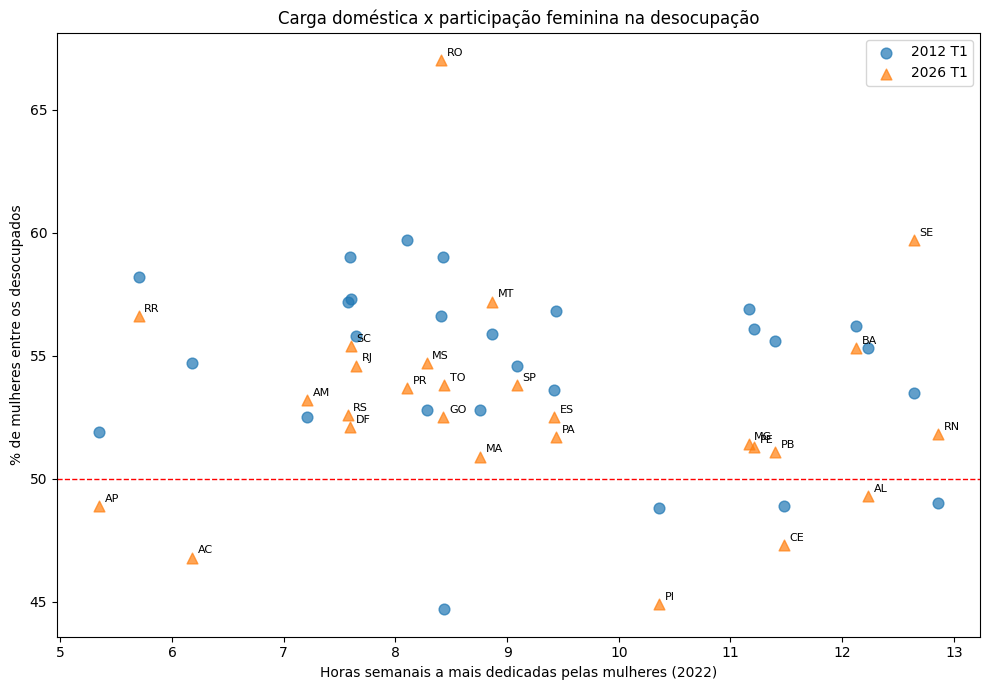

In [19]:
# Gráfico de dispersão: horas a mais das mulheres x participação feminina na desocupação
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(final["Dif_horas_M_H"], final["Mulheres_2012"],
           s=60, alpha=0.7, label="2012 T1")
ax.scatter(final["Dif_horas_M_H"], final["Mulheres_2026"],
           s=60, alpha=0.7, marker="^", label="2026 T1")

# Escrevendo a sigla do estado ao lado de cada ponto de 2026
for _, linha in final.iterrows():
    ax.annotate(linha["Sigla"],
                (linha["Dif_horas_M_H"], linha["Mulheres_2026"]),
                fontsize=8, xytext=(4, 3), textcoords="offset points")

ax.axhline(50, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Horas semanais a mais dedicadas pelas mulheres (2022)")
ax.set_ylabel("% de mulheres entre os desocupados")
ax.set_title("Carga doméstica x participação feminina na desocupação")
ax.legend()
plt.tight_layout()
plt.show()

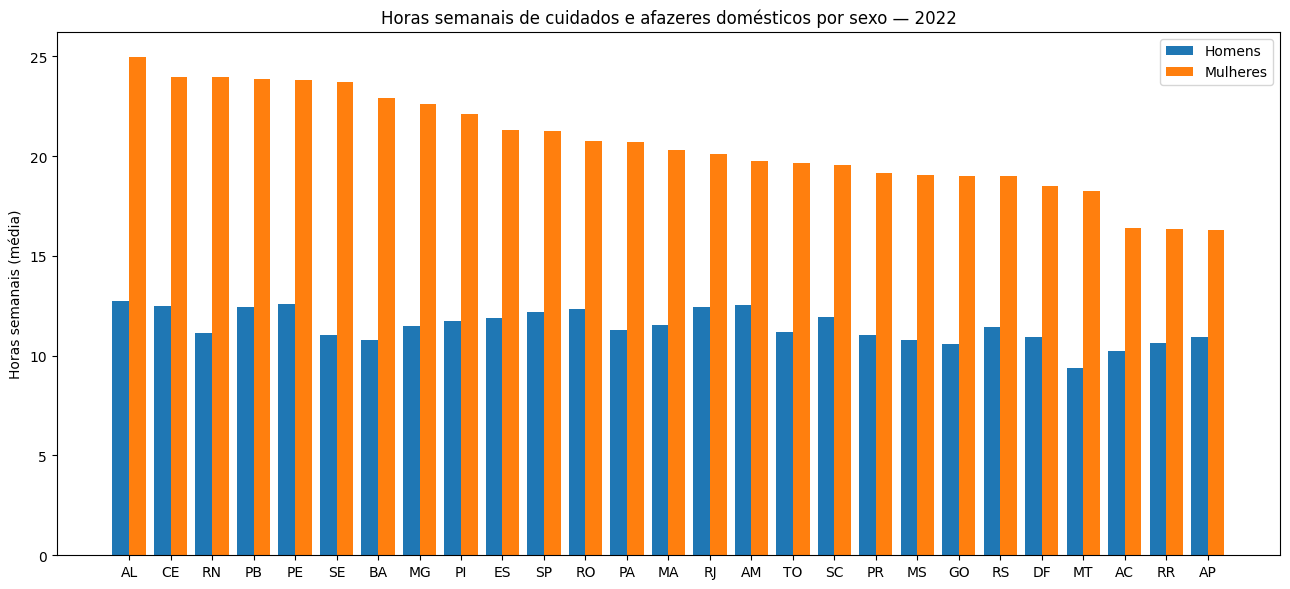

In [20]:
# Gráfico: horas semanais de afazeres domésticos por sexo, em cada estado
g3 = final.sort_values("Horas_mulheres", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(g3))
largura = 0.4

ax.bar([i - largura/2 for i in x], g3["Horas_homens"],   width=largura, label="Homens")
ax.bar([i + largura/2 for i in x], g3["Horas_mulheres"], width=largura, label="Mulheres")

ax.set_xticks(list(x))
ax.set_xticklabels(g3["Sigla"])
ax.set_ylabel("Horas semanais (média)")
ax.set_title("Horas semanais de cuidados e afazeres domésticos por sexo — 2022")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Salvando a tabela final

In [21]:
# Salvando em CSV no padrão brasileiro (para abrir direto no Excel)
final.to_csv("tabela_final_cruzada.csv", sep=";", decimal=",",
             index=False, encoding="utf-8-sig")

print("Arquivo 'tabela_final_cruzada.csv' salvo com sucesso!")
print("Linhas:", len(final), "| Colunas:", len(final.columns))

Arquivo 'tabela_final_cruzada.csv' salvo com sucesso!
Linhas: 27 | Colunas: 15


## 8. Conclusões

In [22]:
# Números que vão embasar as conclusões escritas abaixo
print("1) Em 2012, as mulheres eram maioria dos desocupados em",
      (comp["Mulheres_2012"] > 50).sum(), "dos 27 estados.")
print("   Em 2026, em", (comp["Mulheres_2026"] > 50).sum(), "dos 27 estados.")
print()
print(f"2) Diferença média mulheres - homens em 2012: {comp['Dif_M_H_2012'].mean():.2f} p.p.")
print(f"   Diferença média mulheres - homens em 2026: {comp['Dif_M_H_2026'].mean():.2f} p.p.")
print()
print(f"3) Média de horas semanais de afazeres domésticos (2022):")
print(f"   homens  : {final['Horas_homens'].mean():.2f} h")
print(f"   mulheres: {final['Horas_mulheres'].mean():.2f} h")
print(f"   diferença: {final['Dif_horas_M_H'].mean():.2f} h a mais para as mulheres")
print()
print(f"4) Correlação (horas a mais x % mulheres desocupadas) em 2026: {cor_2026:.3f}")

1) Em 2012, as mulheres eram maioria dos desocupados em 23 dos 27 estados.
   Em 2026, em 22 dos 27 estados.

2) Diferença média mulheres - homens em 2012: 9.14 p.p.
   Diferença média mulheres - homens em 2026: 5.93 p.p.

3) Média de horas semanais de afazeres domésticos (2022):
   homens  : 11.47 h
   mulheres: 20.64 h
   diferença: 9.17 h a mais para as mulheres

4) Correlação (horas a mais x % mulheres desocupadas) em 2026: -0.069


**Escreva aqui as suas conclusões, usando os números impressos acima. Sugestões do que comentar:**

1. **Comparação 2012 x 2026:** as mulheres continuam sendo a maioria dos desocupados na maior
   parte dos estados, mas a diferença em relação aos homens **diminuiu** no período — ou seja,
   a composição da desocupação ficou um pouco mais equilibrada entre os sexos.

2. **Diferenças regionais:** os estados não se moveram todos no mesmo sentido. Alguns tiveram
   queda forte na participação feminina e outros tiveram alta (veja as listas de maiores quedas
   e maiores altas na seção 4).

3. **Cruzamento com a Tabela 1.1.1:** em **todos** os estados as mulheres dedicam bem mais horas
   semanais a cuidados e afazeres domésticos do que os homens. Essa sobrecarga aparece no país
   inteiro, junto com a maior participação feminina na desocupação.

4. **Mas atenção ao resultado da correlação:** ela ficou **próxima de zero**. Isso quer dizer que,
   comparando um estado com o outro, quem tem a maior diferença de horas domésticas **não é
   necessariamente** quem tem a maior participação feminina na desocupação. Ou seja: a sobrecarga
   é um fenômeno nacional, mas as variações entre estados parecem depender de outros fatores
   (estrutura econômica local, setores de emprego, escolaridade etc.).

5. **Cuidado com a interpretação:** correlação mostra apenas se duas variáveis andam juntas —
   ela **não prova causa e efeito**. Os anos também são diferentes (desocupação de 2012 e 2026,
   afazeres domésticos de 2022), então o cruzamento é uma leitura exploratória.

**Limitações do trabalho:**
- As horas por sexo foram obtidas pela **média simples** entre "Branca" e "Preta ou parda",
  sem ponderar pelo tamanho de cada grupo na população.
- A Tabela 1.1.1 é de 2022, ou seja, não coincide exatamente com nenhum dos dois anos das Tabelas 5.
- As Tabelas 5 mostram **composição** (%), e não a taxa de desocupação de cada sexo.